Sample:  deltaRT_nophage
{'A': 0.23, 'T': 0.276, 'C': 0.285, 'G': 0.208}


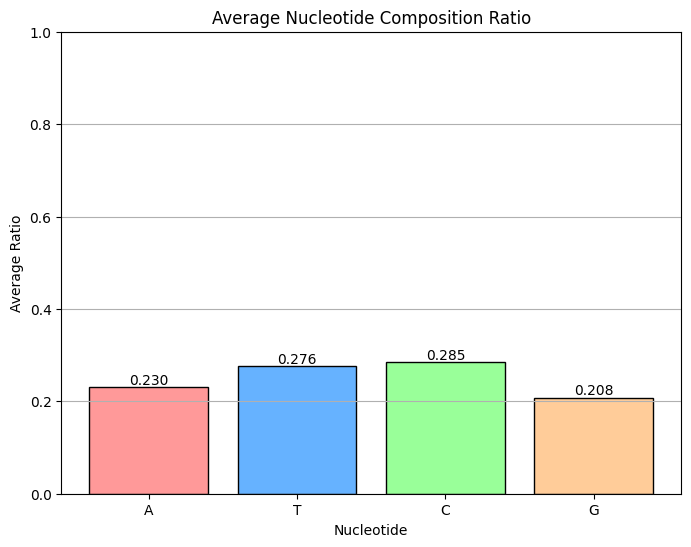

Max length:  75
Min length:  13


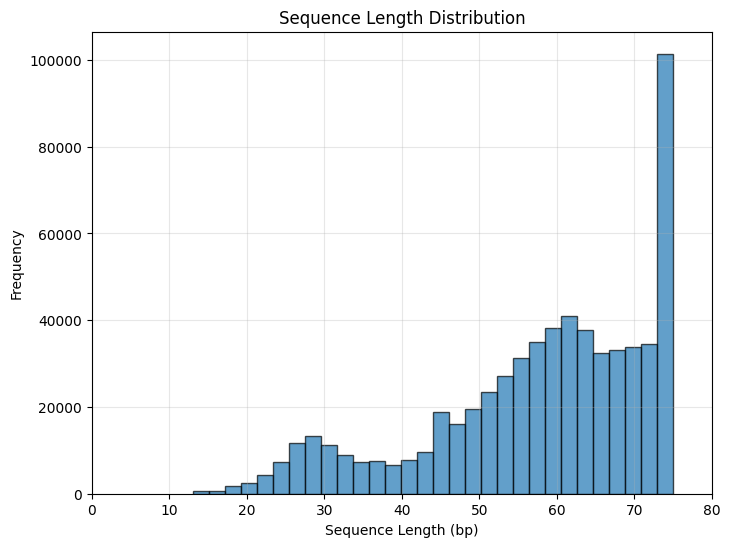

Sample:  deltaRT_T4
{'A': 0.243, 'T': 0.294, 'C': 0.273, 'G': 0.189}


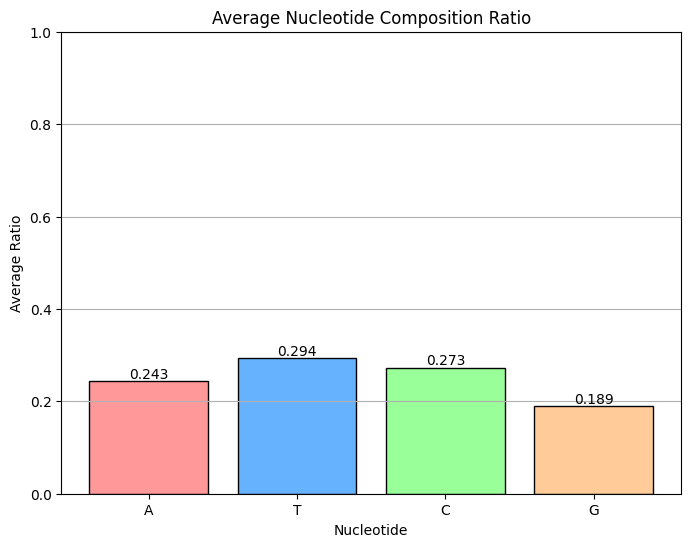

Max length:  75
Min length:  12


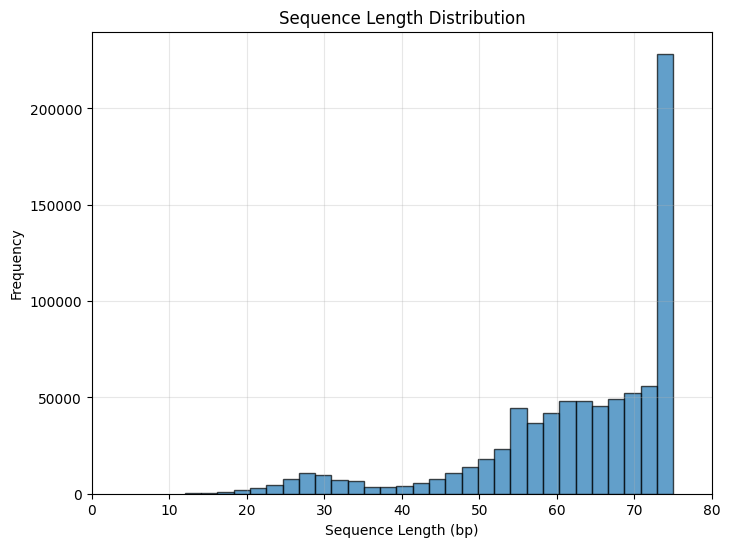

Sample:  pure_DRT1_dNTP
{'A': 0.562, 'T': 0.134, 'C': 0.102, 'G': 0.202}


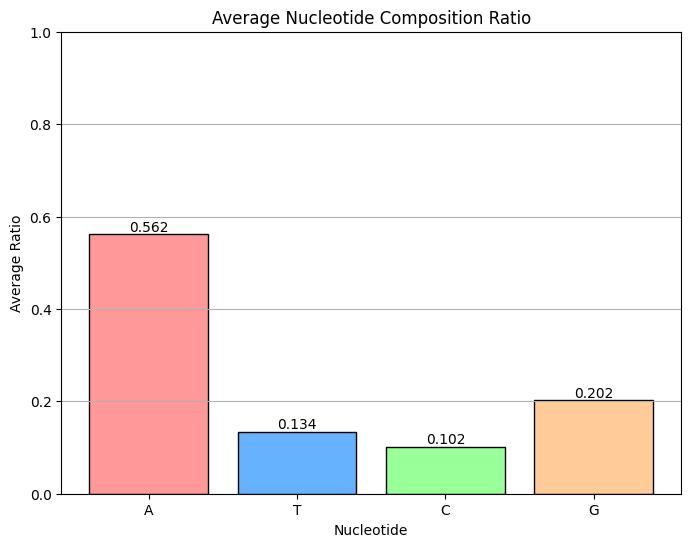

Max length:  75
Min length:  12


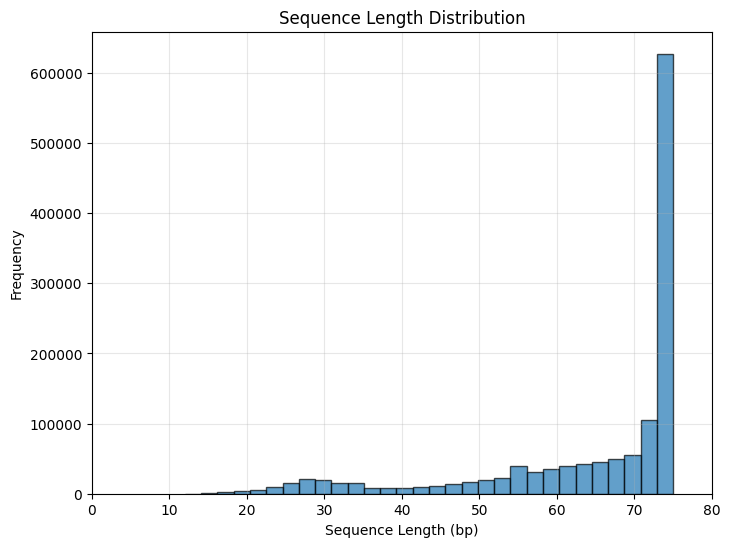

Sample:  pure_DRT1_native
{'A': 0.175, 'T': 0.241, 'C': 0.326, 'G': 0.258}


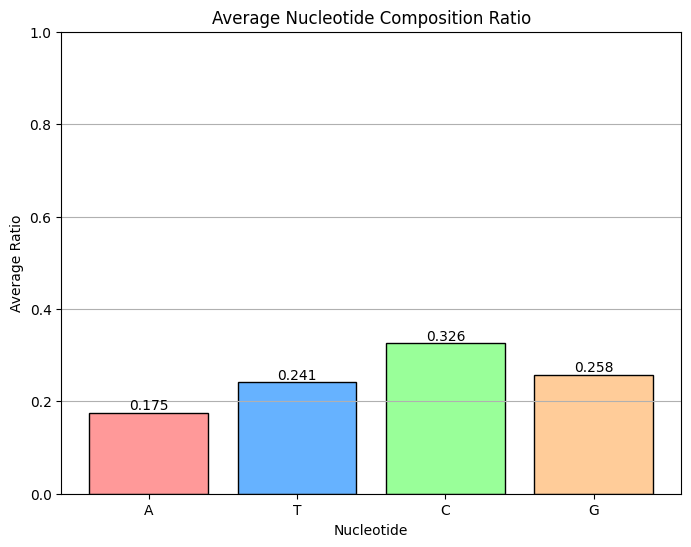

Max length:  75
Min length:  12


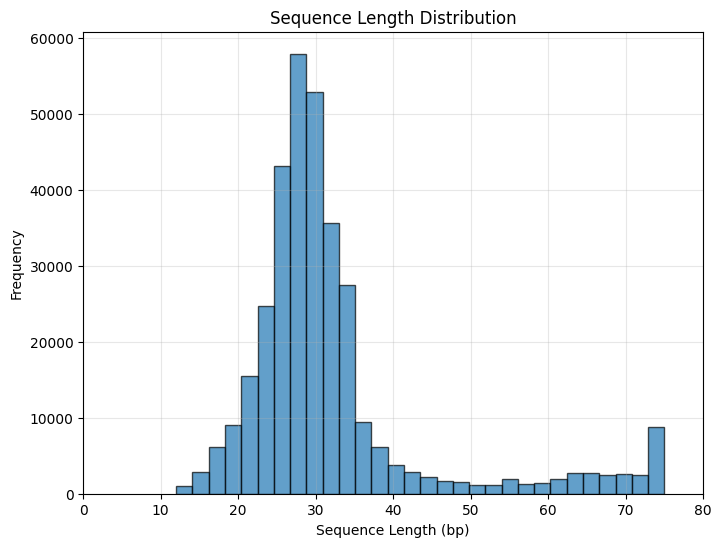

Sample:  WT_nophage
{'A': 0.233, 'T': 0.279, 'C': 0.282, 'G': 0.207}


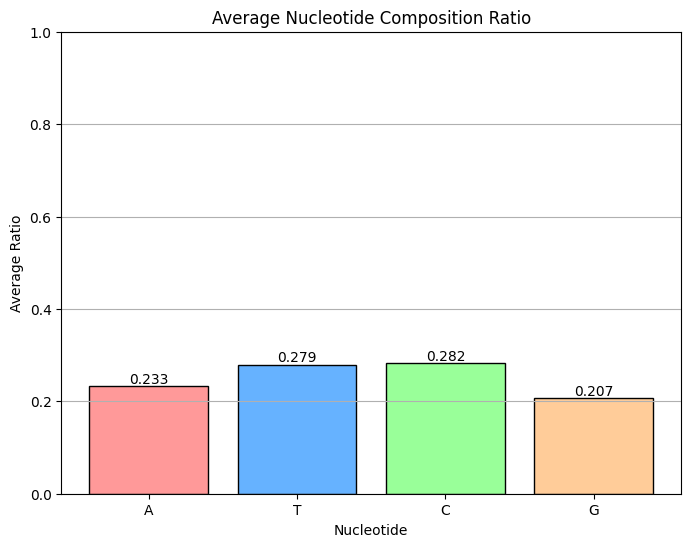

Max length:  75
Min length:  13


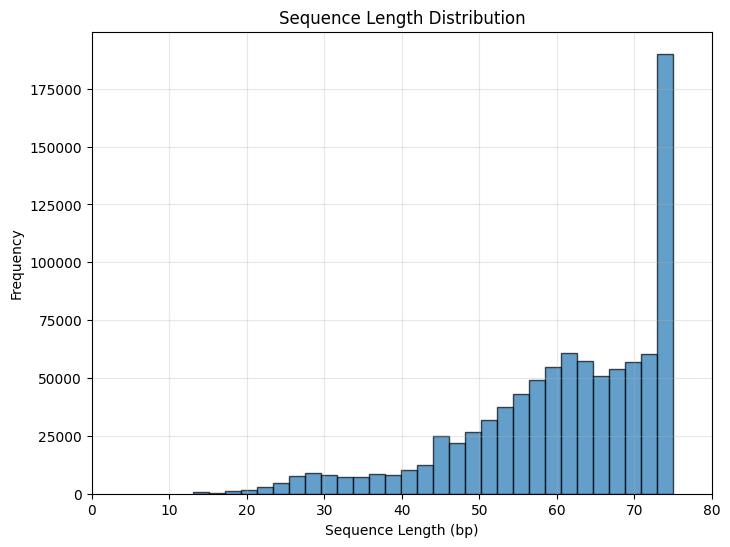

Sample:  WT_T4
{'A': 0.248, 'T': 0.297, 'C': 0.265, 'G': 0.19}


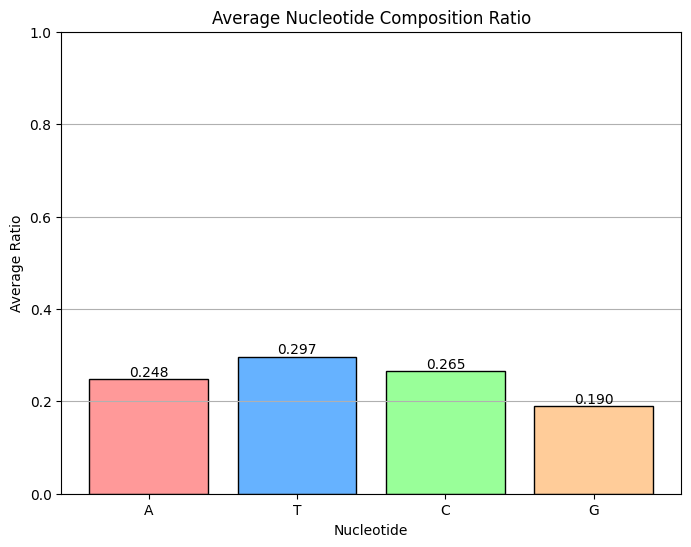

Max length:  75
Min length:  13


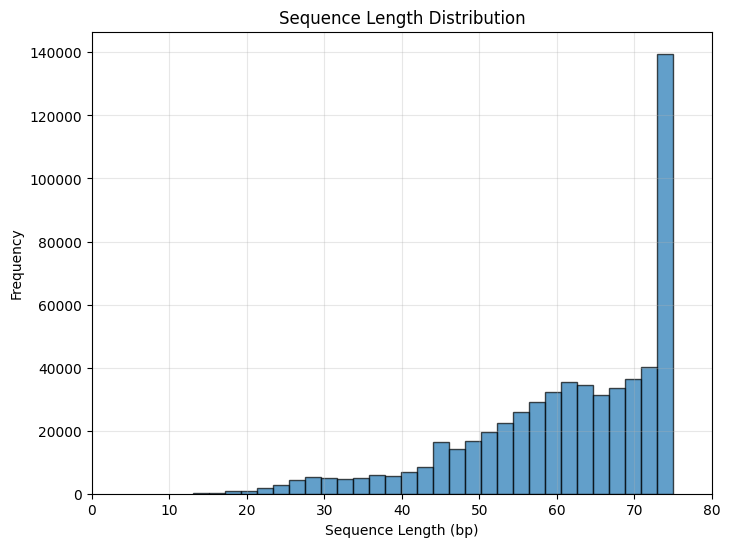

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

def read_fasta(file_path):
    sequences = []
    seq_ids = []
    current_seq = ""
    current_id = ""
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_seq:
                    sequences.append(current_seq)
                    seq_ids.append(current_id)
                    current_seq = ""
                current_id = line[1:]  # Remove '>' from ID
            else:
                current_seq += line
        if current_seq:
            sequences.append(current_seq)
            seq_ids.append(current_id)
    return seq_ids, sequences

def calculate_nucleotide_ratios(sequences, seq_ids, file):
    seq_ratio_dict = {}
    all_ratios = {'A': [], 'T': [], 'C': [], 'G': []}
    rich_a_sequences = []
    rich_a_ids = []
    rich_t_sequences = []
    rich_t_ids = []

    for seq_id, seq in zip(seq_ids, sequences):
        nucleotide_counts = Counter(seq.upper())
        total = sum(nucleotide_counts.values())
        
        # Calculate ratios for this sequence
        ratios = {
            'A': nucleotide_counts.get('A', 0) / total,
            'T': nucleotide_counts.get('T', 0) / total,
            'C': nucleotide_counts.get('C', 0) / total,
            'G': nucleotide_counts.get('G', 0) / total
        }
        seq_ratio_dict[seq_id] = ratios
        
        # Check for A or T >= 70%
        if ratios['A'] >= 0.7:
            rich_a_sequences.append(seq)
            rich_a_ids.append(seq_id)
        if ratios['T'] >= 0.7:
            rich_t_sequences.append(seq)
            rich_t_ids.append(seq_id)
        
        # Store ratios for averaging
        for nuc in all_ratios:
            all_ratios[nuc].append(ratios[nuc])
    
    # Calculate average ratios
    avg_ratios = {
        nuc: round(np.mean(ratios), 3) if ratios else 0
        for nuc, ratios in all_ratios.items()
    }
    
    file_prefix = file.strip(".fasta")
    rich_a_file = f"/mnt/home/cchiang/Nolan_ssDNA_sequencing/{file_prefix}_richA.fasta"
    with open(rich_a_file, 'w') as f:
        for seq_id, seq in zip(rich_a_ids, rich_a_sequences):
            f.write(f">{seq_id}\n{seq}\n")

    rich_t_file = f"/mnt/home/cchiang/Nolan_ssDNA_sequencing/{file_prefix}_richT.fasta"
    with open(rich_t_file, 'w') as f:
        for seq_id, seq in zip(rich_t_ids, rich_t_sequences):
            f.write(f">{seq_id}\n{seq}\n")

    return seq_ratio_dict, avg_ratios

fasta_files = ["deltaRT_nophage", "deltaRT_T4",
               "pure_DRT1_dNTP", "pure_DRT1_native",
               "WT_nophage", "WT_T4"]

for file in fasta_files:
    print("Sample: ", file)
    seq_ids, sequences = read_fasta(f"/mnt/home/cchiang/Nolan_ssDNA_sequencing/{file}.fasta")
    seq_ratio_dict, avg_ratios = calculate_nucleotide_ratios(sequences, seq_ids, file)
    print(avg_ratios)

    # Nucleotide ratio
    nucleotides = ['A', 'T', 'C', 'G']
    ratios = [avg_ratios[nuc] for nuc in nucleotides]
    plt.figure(figsize=(8, 6))
    bars = plt.bar(nucleotides, np.array(ratios), edgecolor='black', color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
    plt.title('Average Nucleotide Composition Ratio')
    plt.xlabel('Nucleotide')
    plt.ylabel('Average Ratio')
    plt.ylim(0, 1)
    plt.grid(True, axis='y', alpha=1)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom')
    plt.savefig(f"/mnt/home/cchiang/Nolan_ssDNA_sequencing/{file}_ratio.png")
    plt.show()

    # Length distribution
    lengths = [len(seq) for seq in sequences]
    print("Max length: ", max(lengths))
    print("Min length: ", min(lengths))
    plt.figure(figsize=(8, 6))
    plt.hist(lengths, bins=30, edgecolor='black', alpha=0.7)
    plt.title('Sequence Length Distribution')
    plt.xlabel('Sequence Length (bp)')
    plt.ylabel('Frequency')
    plt.xlim(0, 80)
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/mnt/home/cchiang/Nolan_ssDNA_sequencing/{file}_lendist.png")
    plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

def read_fasta(file_path):
    sequences = []
    seq_ids = []
    current_seq = ""
    current_id = ""
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_seq:
                    sequences.append(current_seq)
                    seq_ids.append(current_id)
                    current_seq = ""
                current_id = line[1:]  # Remove '>' from ID
            else:
                current_seq += line
        if current_seq:
            sequences.append(current_seq)
            seq_ids.append(current_id)
    return seq_ids, sequences

def calculate_nucleotide_ratios(sequences, seq_ids, file):
    seq_ratio_dict = {}
    all_ratios = {'A': [], 'T': [], 'C': [], 'G': []}
    rich_a_sequences = []
    rich_a_ids = []
    rich_t_sequences = []
    rich_t_ids = []

    
    for seq_id, seq in zip(seq_ids, sequences):
        nucleotide_counts = Counter(seq.upper())
        total = sum(nucleotide_counts.values())
        
        # Calculate ratios for this sequence
        ratios = {
            'A': nucleotide_counts.get('A', 0) / total,
            'T': nucleotide_counts.get('T', 0) / total,
            'C': nucleotide_counts.get('C', 0) / total,
            'G': nucleotide_counts.get('G', 0) / total
        }
        seq_ratio_dict[seq_id] = ratios
        
        # Store ratios for averaging
        for nuc in all_ratios:
            all_ratios[nuc].append(ratios[nuc])
    
    # Calculate average ratios
    avg_ratios = {
        nuc: round(np.mean(ratios), 3) if ratios else 0
        for nuc, ratios in all_ratios.items()
    }

    return seq_ratio_dict, avg_ratios


seq_ids, sequences = read_fasta("/mnt/home/cchiang/Nolan_ssDNA_sequencing/pure_DRT1_dNTP_richA.fasta")
seq_ratio_dict, avg_ratios = calculate_nucleotide_ratios(sequences, seq_ids, file)
print(avg_ratios)

{'A': 0.811, 'T': 0.042, 'C': 0.022, 'G': 0.125}
